C:\Users\smumm\AppData\Local\Temp\ipykernel_30044\1383675324.py:10: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  survival_df = df.groupby('battery_id').apply(lambda g: pd.Series({


EOL batteries: 12.0 / 23


<lifelines.CoxPHFitter: fitted with 23 total observations, 11 right-censored observations>
             duration col = 'duration'
                event col = 'event'
                penalizer = 0.1
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 23
number of events observed = 12
   partial log-likelihood = -19.86
         time fit was run = 2026-04-10 16:41:24 UTC

---
            coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                   
mean_Re    23.76  2.07e+10     14.48           -4.63           52.14                0.01            4.39e+22
mean_Rct   16.71  1.81e+07      9.54           -1.99           35.41                0.14            2.39e+15
mean_gas    0.00      1.00      0.01           -0.02            0.02                0.98                1.02
mean_smoke  1.28      3.60      1.88           -2.41            4.97                0.09              144.03

            cmp to    z    p  -log2(p)
covariate                             
mean_Re       0.00 1.64 0.10      3.31
mean_Rct      0.00 1.75 0.08      3.65
mean_gas      0.00 0.02 0.99      0.02
mean_smoke    0.00 0.68 0.50      1.01
---
Concordance = 0.79
Partial AIC = 47.73
log-likelihood ratio test = 11.10 on 4 df
-log2(p) of ll-ratio test = 5.30

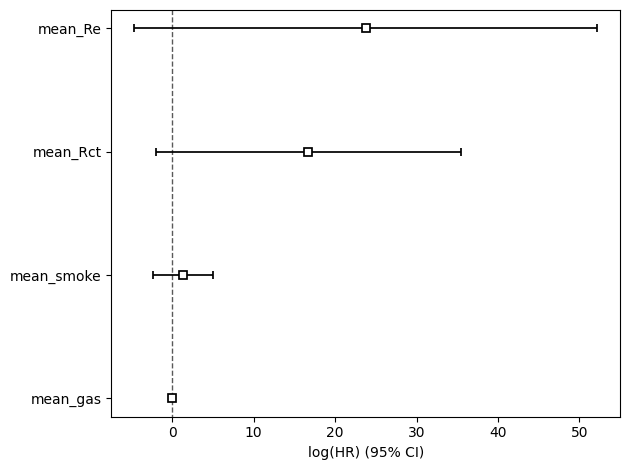

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from lifelines import CoxPHFitter

# Use Day1's processed dataset, which includes SoH and engineered features.
df = pd.read_csv('nasa_processed.csv')

# CoxPHFitter is a survival analysis model that helps estimate how features
# affect time-to-failure (here, battery end-of-life behavior).
survival_df = df.groupby('battery_id').apply(lambda g: pd.Series({
    'duration':   len(g),
    'event':      int((g['SoH'] < 80).any()),
    'mean_Re':    g['Re'].mean(),
    'mean_Rct':   g['Rct'].mean(),
    'mean_gas':   g['gas_ppm'].mean(),
    'mean_smoke': g['smoke_density'].mean(),
})).reset_index(drop=True)

print(f"EOL batteries: {survival_df['event'].sum()} / {len(survival_df)}")

# penalizer=0.1 for stability on small dataset
cph = CoxPHFitter(penalizer=0.1)
cph.fit(survival_df, duration_col='duration', event_col='event')
cph.print_summary()

# exp(coef) > 1 means higher value is associated with faster failure
cph.plot()
plt.tight_layout()
plt.savefig('data/cox_model.png', dpi=150)
plt.show()

MAE: 38.81 cycles
R2:  0.818


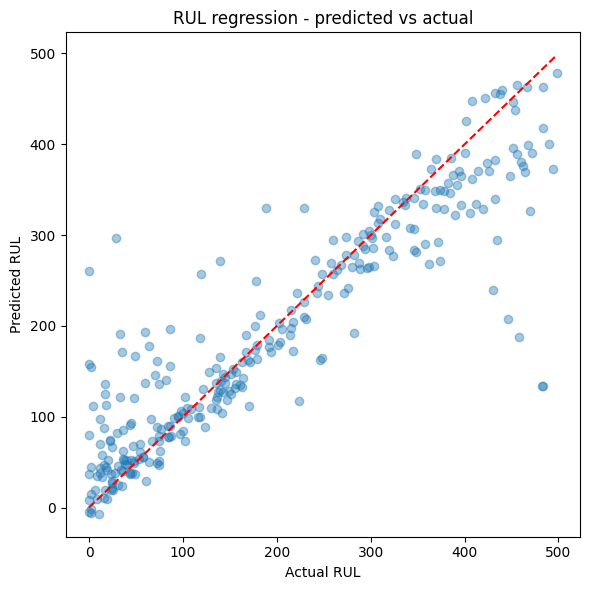

Saved scaler and regressor.


In [6]:
from pathlib import Path
import joblib
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Keep Cell 2 runnable even if Cell 1 has not been executed in this kernel.
if 'df' not in globals():
    df = pd.read_csv('nasa_processed.csv')

SENSOR_FEATURES = [
    'Re', 'Rct', 'total_impedance',
    'capacity_fade', 'cumulative_fade',
    'ambient_temperature', 'gas_ppm', 'smoke_density'
]

df_s = df.sort_values(['battery_id', 'test_id']).copy()
df_s['rul'] = df_s.groupby('battery_id')['test_id'].transform(
    lambda x: x.max() - x)

scaler = StandardScaler()
X_rul = pd.DataFrame(
    scaler.fit_transform(df_s[SENSOR_FEATURES]),
    columns=SENSOR_FEATURES)
y_rul = df_s['rul']

X_tr, X_te, y_tr, y_te = train_test_split(
    X_rul, y_rul, test_size=0.2, random_state=42)

reg = GradientBoostingRegressor(n_estimators=100, random_state=42)
reg.fit(X_tr, y_tr)
y_pred_rul = reg.predict(X_te)

print(f'MAE: {mean_absolute_error(y_te, y_pred_rul):.2f} cycles')
print(f'R2:  {r2_score(y_te, y_pred_rul):.3f}')

plt.figure(figsize=(6, 6))
plt.scatter(y_te, y_pred_rul, alpha=0.4)
plt.plot([0, y_te.max()], [0, y_te.max()], 'r--')
plt.xlabel('Actual RUL')
plt.ylabel('Predicted RUL')
plt.title('RUL regression - predicted vs actual')
plt.tight_layout()
plt.savefig('data/rul_regression.png', dpi=150)
plt.show()

Path('pipeline').mkdir(exist_ok=True)
joblib.dump(scaler, 'pipeline/scaler.pkl')
joblib.dump(reg, 'pipeline/regressor.pkl')
print('Saved scaler and regressor.')

In [10]:
print('=== RUL regression performance by temperature condition ===')

from sklearn.metrics import mean_absolute_error, r2_score

for temp in sorted(df['ambient_temperature'].unique()):
    mask = df['ambient_temperature'] == temp
    if mask.sum() < 20:
        continue

    df_temp = df[mask].sort_values(['battery_id', 'test_id']).copy()
    df_temp['rul'] = df_temp.groupby('battery_id')['test_id'].transform(
        lambda x: x.max() - x)

    X_temp = pd.DataFrame(
        scaler.transform(df_temp[SENSOR_FEATURES]),
        columns=SENSOR_FEATURES)
    y_temp = df_temp['rul']
    preds = reg.predict(X_temp)

    print(f'Temp: {temp}C  (n={len(df_temp)})')
    print(f'  MAE: {mean_absolute_error(y_temp, preds):.2f} cycles')
    print(f'  R2 : {r2_score(y_temp, preds):.3f}')
    print('-' * 45)

=== RUL regression performance by temperature condition ===
Temp: 24C  (n=1408)
  MAE: 30.86 cycles
  R2 : 0.888
---------------------------------------------
Temp: 43C  (n=64)
  MAE: 10.94 cycles
  R2 : 0.694
---------------------------------------------
